# EDA — NovaPay: Detección de Fraude (Ronda 2 — v3)

Dataset `dataset_fraude_v3.csv` generado para la segunda ronda de mejora del modelo.
El objetivo es entender la distribución de las nuevas variables, confirmar que los patrones Ciber (fraude silencioso y burst) son distinguibles en los datos, y detectar posibles problemas antes del reentrenamiento.

**Diferencias clave respecto a v2:**
- 100.000 registros vs 10.000 (×10)
- ~3,5% de fraude vs ~15% — proporción más realista de producción
- Nuevos patrones inyectados: fraude silencioso (importe bajo, doméstico) y burst (ráfaga de transferencias)

## 1. Setup e imports

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 100, 'figure.figsize': (10, 5)})
sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', 50)

## 2. Carga y exploración inicial

### 2.1 Carga del dataset

In [2]:
df = pd.read_csv('../data/dataset_fraude_v3.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (100000, 44)


,id_cliente,tipo_cliente,edad_cliente,customer_country,customer_region,tenure,importe_medio_mensual,desviacion_estandar_mensual,media_transacciones_al_dia,numero_fraudes_ultimo_ano,id_cuenta,cuenta_origen,estado_cuenta,saldo_actual,saldo_medio_30_dias,volumen_entrante_30_dias,volumen_saliente_30_dias,numero_transferencias_recibidas_7_dias,numero_transferencias_enviadas_7_dias,id_tarjeta,estado_tarjeta,fecha_creacion_tarjeta,antiguedad_tarjeta_dias,limite_importe_transacciones,veces_superar_limite_7_dias,id_transaccion,tipo_transaccion,fecha_hora,is_night,is_weekend,tiempo_desde_ultima_transaccion,numero_transacciones_ultima_hora,importe_transaccion,metodo_autenticacion,numero_pin_disponibles,identificador_dispositivo_fingerprint,dispositivo_reconocido,operacion_pais,operacion_region,direccion_ip_origen,geolocalizacion,cuenta_destino,destino_alto_riesgo,IS_FRAUD
0,458081ad-c1b,persona,52,ES,Este,1875,436.92,104.72,1.78,0,a4970c26-f44,ES427733427957,activa,697.03,837.04,15241.61,2616.53,2,0,fac00e42-f16,caducada,2023-10-25,945,3000,1,453bf0ed-d64,tarjeta,2026-01-03T18:15:13,0,1,46778,3,1300.25,3DS,1,9171e0d3-5084-48,1,ES,Este,86.107.101.44,"41.3874,2.1686",ES211249659341,0,0
1,704e6bdf-bf2,persona,63,ES,Norte,87,1387.02,1297.72,2.95,0,de92671b-272,ES659918119226,activa,27118.17,21470.54,22145.51,5344.91,0,1,b2f245e6-66e,activa,2022-08-22,1374,3000,0,b0895fba-e77,tarjeta,2026-05-04T22:40:07,0,0,5171,2,85.26,3DS,1,da5d5f8f-f980-42,1,ES,Este,86.220.171.20,"37.3891,-5.9845",ES712294446334,0,0
2,517a01a3-d06,empresa,70,ES,Sur,2608,511.04,49.90,1.66,0,99388060-79d,ES743079549550,activa,7543.42,9001.62,12491.79,88717.86,4,4,ff1a1d5e-a63,activa,2024-11-05,568,500,0,af09e842-ba6,tarjeta,2026-05-02T08:11:00,0,1,31600,6,933.64,PIN,2,16eb3b09-bb3c-40,0,IT,Campania,86.209.31.83,"39.4699,-0.3763",ES504717922313,0,1
3,f6fee85e-440,persona,27,ES,Oeste,3125,584.43,104.62,1.47,0,57540d1f-ad3,ES153656473669,activa,174.53,146.31,8918.19,1469.48,4,0,bcbbb52a-68e,activa,2024-02-25,822,2000,0,bb3b455e-390,tarjeta,2026-03-31T07:45:15,0,0,31995,2,117.06,PIN,2,27c531ea-3c88-49,0,ES,Oeste,86.252.240.122,"39.4699,-0.3763",ES667880381185,0,0
4,23d1d8ff-116,persona,73,GB,Inglaterra,386,88.28,267.80,5.13,0,1125584f-be8,ES883241377645,activa,598.01,715.60,3746.85,3310.55,4,1,a8ae4fb2-893,activa,2024-10-25,579,5000,0,00e52047-71e,transferencia,2026-01-01T10:58:01,0,0,13593,2,490.95,3DS,2,40193ea7-9f89-41,0,GB,Inglaterra,81.241.25.133,"55.9533,-3.1883",ES554525552882,0,0


### 2.2 Limpieza inicial y extracción temporal

In [3]:
# Eliminamos columnas de impacto económico si existen
for col in ['IMPACTO_FRAUDE']:
    if col in df.columns:
        df.drop(columns=[col], inplace=True)

# Descomponemos fecha_hora
df['fecha_hora'] = pd.to_datetime(df['fecha_hora'])
df['fecha']     = df['fecha_hora'].dt.date
df['hora']      = df['fecha_hora'].dt.hour
df['dia_semana']= df['fecha_hora'].dt.dayofweek
df['mes']       = df['fecha_hora'].dt.month

print('Columnas tras limpieza:', df.shape[1])

Columnas tras limpieza: 48


### 2.3 Inspección general

In [4]:
# Nulos
nulos = df.isna().sum()
print('Columnas con nulos:', (nulos > 0).sum())
nulos[nulos > 0]

Columnas con nulos: 0


Series([], dtype: int64)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 48 columns):
 #   Column                                  Non-Null Count   Dtype         
---  ------                                  --------------   -----         
 0   id_cliente                              100000 non-null  object        
 1   tipo_cliente                            100000 non-null  object        
 2   edad_cliente                            100000 non-null  int64         
 3   customer_country                        100000 non-null  object        
 4   customer_region                         100000 non-null  object        
 5   tenure                                  100000 non-null  int64         
 6   importe_medio_mensual                   100000 non-null  float64       
 7   desviacion_estandar_mensual             100000 non-null  float64       
 8   media_transacciones_al_dia              100000 non-null  float64       
 9   numero_fraudes_ultimo_ano             

In [6]:
df.describe()

,edad_cliente,tenure,importe_medio_mensual,desviacion_estandar_mensual,media_transacciones_al_dia,numero_fraudes_ultimo_ano,saldo_actual,saldo_medio_30_dias,volumen_entrante_30_dias,volumen_saliente_30_dias,numero_transferencias_recibidas_7_dias,numero_transferencias_enviadas_7_dias,antiguedad_tarjeta_dias,limite_importe_transacciones,veces_superar_limite_7_dias,fecha_hora,is_night,is_weekend,tiempo_desde_ultima_transaccion,numero_transacciones_ultima_hora,importe_transaccion,numero_pin_disponibles,dispositivo_reconocido,destino_alto_riesgo,IS_FRAUD,hora,dia_semana,mes
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000,100000.000000,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50.647390,1818.811280,850.495982,496.104215,3.432023,0.428400,3577.095165,3599.235114,9455.376529,9.109672e+03,3.046460,2.008580,908.933710,1702.545000,0.306860,2026-02-25 05:39:49.355110144,0.293560,0.283040,2.219774e+06,2.162730,470.565658,1.813780,0.834440,0.132520,0.035340,11.470790,2.989770,4.716760
min,18.000000,0.000000,4.820000,0.080000,0.500000,0.000000,1.350000,1.460000,12.780000,1.025000e+01,0.000000,0.000000,1.000000,500.000000,0.000000,2025-11-25 21:57:31,0.000000,0.000000,0.000000e+00,0.000000,0.080000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,34.000000,885.000000,183.060000,149.280000,1.340000,0.000000,411.530000,403.460000,1109.130000,1.066740e+03,2.000000,1.000000,454.000000,1000.000000,0.000000,2026-01-10 12:27:00.500000,0.000000,0.000000,0.000000e+00,1.000000,54.620000,1.000000,1.000000,0.000000,0.000000,5.000000,1.000000,2.000000
50%,50.000000,1814.000000,406.910000,354.510000,2.555000,0.000000,1103.560000,1096.020000,2990.560000,2.974790e+03,3.000000,2.000000,900.000000,2000.000000,0.000000,2026-02-25 05:43:05.500000,0.000000,0.000000,4.207250e+04,2.000000,152.335000,2.000000,1.000000,0.000000,0.000000,11.000000,3.000000,4.000000
75%,68.000000,2741.000000,958.590000,679.330000,4.560000,1.000000,2988.580000,2967.300000,8316.190000,7.984320e+03,4.000000,3.000000,1368.000000,2000.000000,1.000000,2026-04-11 17:45:27,1.000000,1.000000,3.614057e+06,3.000000,422.880000,2.000000,1.000000,0.000000,0.000000,18.000000,5.000000,5.000000
max,84.000000,3647.000000,58540.500000,5276.170000,23.200000,6.000000,427325.920000,499626.050000,974942.410000,2.872430e+06,12.000000,9.000000,1827.000000,5000.000000,4.000000,2026-05-27 10:21:12,1.000000,1.000000,1.575060e+07,19.000000,76603.550000,3.000000,1.000000,1.000000,1.000000,23.000000,6.000000,12.000000
std,19.490469,1053.467358,1774.244255,488.363335,2.901329,0.734533,11667.142985,12440.875180,27464.588454,2.475820e+04,1.738647,1.394333,525.207829,1120.919528,0.552576,NaN,0.455395,0.450478,3.537208e+06,1.979285,1304.033864,0.753663,0.371687,0.339057,0.184639,6.939087,1.996313,3.765105


In [7]:
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
print('Columnas categóricas:', categorical_cols)

Columnas categóricas: ['id_cliente', 'tipo_cliente', 'customer_country', 'customer_region', 'id_cuenta', 'cuenta_origen', 'estado_cuenta', 'id_tarjeta', 'estado_tarjeta', 'fecha_creacion_tarjeta', 'id_transaccion', 'tipo_transaccion', 'metodo_autenticacion', 'identificador_dispositivo_fingerprint', 'operacion_pais', 'operacion_region', 'direccion_ip_origen', 'geolocalizacion', 'cuenta_destino', 'fecha']


## 3. Análisis univariante

### 3.1 Desbalanceo de clases

Conteo absoluto:
IS_FRAUD
0    96466
1     3534
Name: count, dtype: int64

Porcentaje:
IS_FRAUD
0    96.47
1     3.53
Name: proportion, dtype: float64


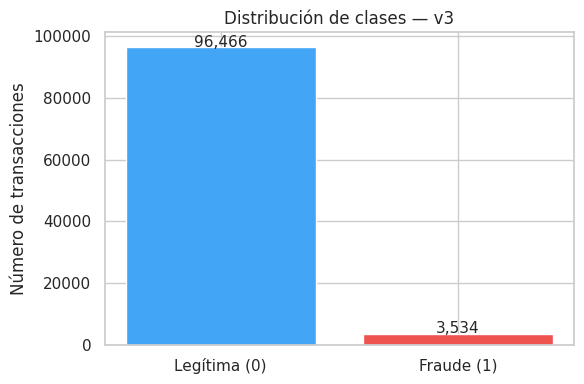

In [8]:
conteo = df['IS_FRAUD'].value_counts().sort_index()
pct    = df['IS_FRAUD'].value_counts(normalize=True).sort_index().mul(100).round(2)

print('Conteo absoluto:')
print(conteo)
print()
print('Porcentaje:')
print(pct)

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['Legítima (0)', 'Fraude (1)'], conteo.values, color=['#42A5F5', '#EF5350'])
for bar, v in zip(bars, conteo.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200, f'{v:,}', ha='center', fontsize=11)
ax.set_title('Distribución de clases — v3')
ax.set_ylabel('Número de transacciones')
plt.tight_layout()
plt.show()

> **Hallazgo 3.1 — Desbalanceo de clases:**
> La tasa de fraude en v3 es ~3,5% frente al 15,3% del v2. Esto representa una proporción más realista de producción y supone un desafío mayor para el modelo: un clasificador trivial que predice siempre "legítima" tiene accuracy del 96,5%, lo que hace imprescindible el uso de PR-AUC y F2-score como métricas principales.
> La ratio legítimas/fraudes es ~27:1, frente al 5,5:1 del v2.

### 3.2 Distribución del importe de transacción

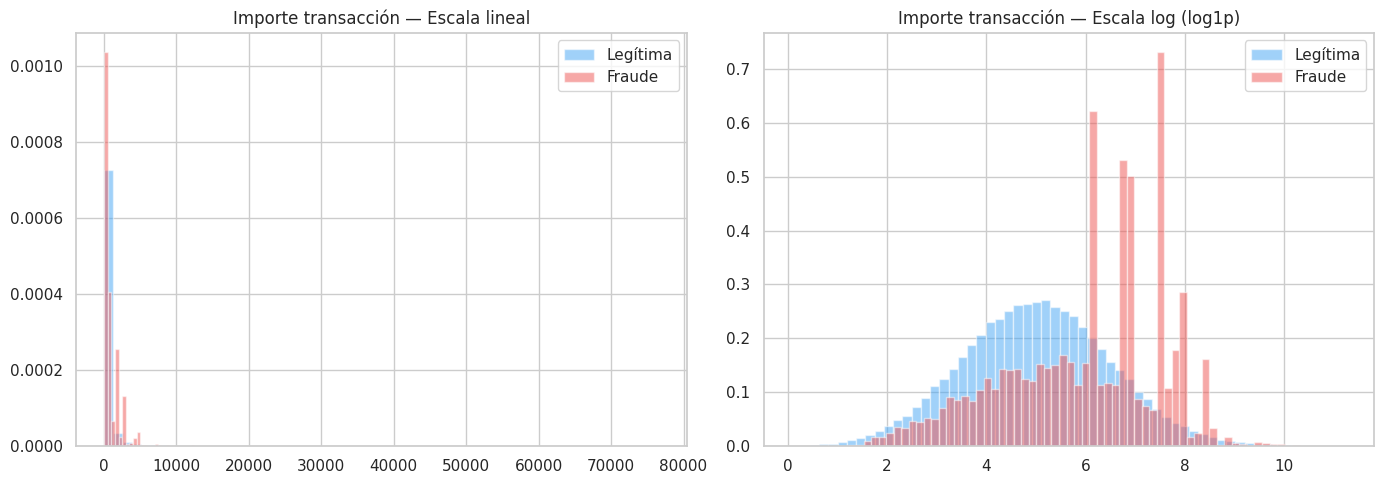

Importe medio legítimas:  451.0
Importe medio fraudes:    1001.0

Fraudes con importe < 300€: 0.374
Legítimas con importe < 300€: 0.684


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, log_scale, title in zip(axes, [False, True], ['Escala lineal', 'Escala log (log1p)']):
    col = np.log1p(df['importe_transaccion']) if log_scale else df['importe_transaccion']
    for label, grupo in df.groupby('IS_FRAUD'):
        vals = np.log1p(grupo['importe_transaccion']) if log_scale else grupo['importe_transaccion']
        ax.hist(vals, bins=60, alpha=0.5, density=True,
                label='Fraude' if label else 'Legítima',
                color='#EF5350' if label else '#42A5F5')
    ax.set_title(f'Importe transacción — {title}')
    ax.legend()

plt.tight_layout()
plt.show()

print('Importe medio legítimas: ', df[df.IS_FRAUD==0]['importe_transaccion'].mean().round(0))
print('Importe medio fraudes:   ', df[df.IS_FRAUD==1]['importe_transaccion'].mean().round(0))
print()
print('Fraudes con importe < 300€:', (df[df.IS_FRAUD==1]['importe_transaccion'] < 300).mean().round(3))
print('Legítimas con importe < 300€:', (df[df.IS_FRAUD==0]['importe_transaccion'] < 300).mean().round(3))

> **Hallazgo 3.2 — Importe de transacción:**
> En v3, los fraudes presentan una distribución bimodal: una cola de importes bajos (<300€) correspondiente al patrón de fraude silencioso inyectado, y una cola alta similar al fraude clásico. Las legítimas también tienen importes bajos frecuentes (contraejemplo anti-overfitting). Esta superposición es correcta y deseable: el modelo no podrá aprender "importe bajo = fraude" como regla dura.

### 3.3 Velocidad de transacciones (número en última hora)

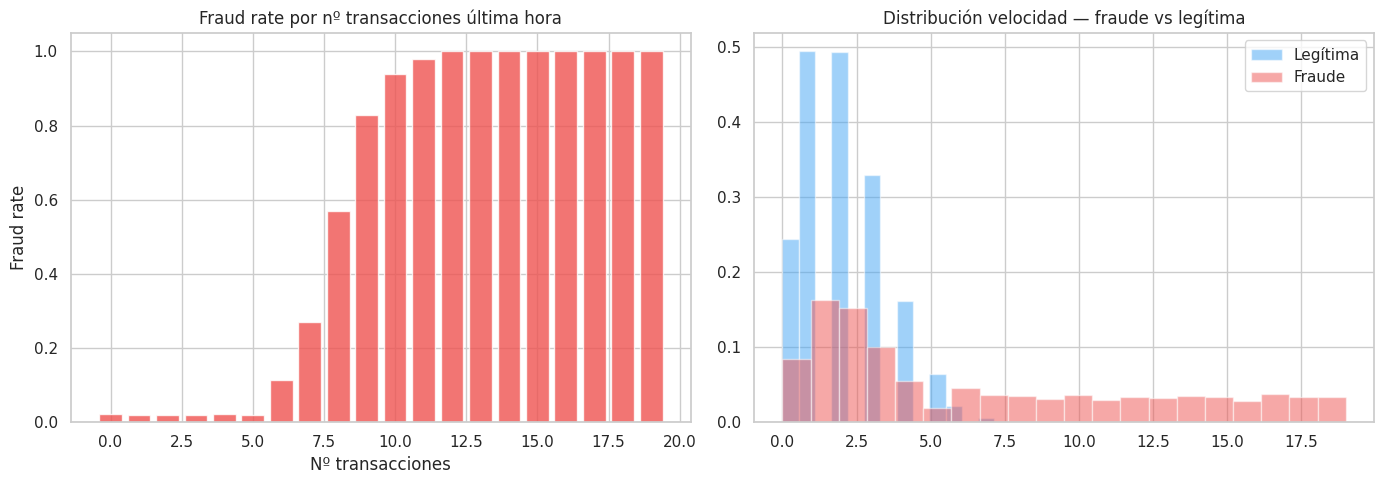

Burst (>5 txns/hora) en fraudes:   0.455
Burst (>5 txns/hora) en legítimas: 0.017


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

resumen_vel = (
    df.groupby('numero_transacciones_ultima_hora')['IS_FRAUD']
    .agg(total='size', fraudes='sum')
    .assign(fraud_rate=lambda x: x.fraudes / x.total)
    .reset_index()
)

axes[0].bar(resumen_vel['numero_transacciones_ultima_hora'],
            resumen_vel['fraud_rate'], color='#EF5350', alpha=0.8)
axes[0].set_title('Fraud rate por nº transacciones última hora')
axes[0].set_xlabel('Nº transacciones')
axes[0].set_ylabel('Fraud rate')

for label, grupo in df.groupby('IS_FRAUD'):
    axes[1].hist(grupo['numero_transacciones_ultima_hora'], bins=20,
                 alpha=0.5, density=True,
                 label='Fraude' if label else 'Legítima',
                 color='#EF5350' if label else '#42A5F5')
axes[1].set_title('Distribución velocidad — fraude vs legítima')
axes[1].legend()

plt.tight_layout()
plt.show()

print('Burst (>5 txns/hora) en fraudes:  ', (df[df.IS_FRAUD==1]['numero_transacciones_ultima_hora'] > 5).mean().round(3))
print('Burst (>5 txns/hora) en legítimas:', (df[df.IS_FRAUD==0]['numero_transacciones_ultima_hora'] > 5).mean().round(3))

> **Hallazgo 3.3 — Velocidad (burst detection):**
> Los fraudes muestran una cola claramente más gruesa en valores altos (>5 txns/hora), patrón del burst fraud inyectado. La señal es visible pero no perfectamente separable — hay legítimas con alta velocidad también, lo que es correcto para evitar overfitting.

### 3.4 Tiempo desde última transacción

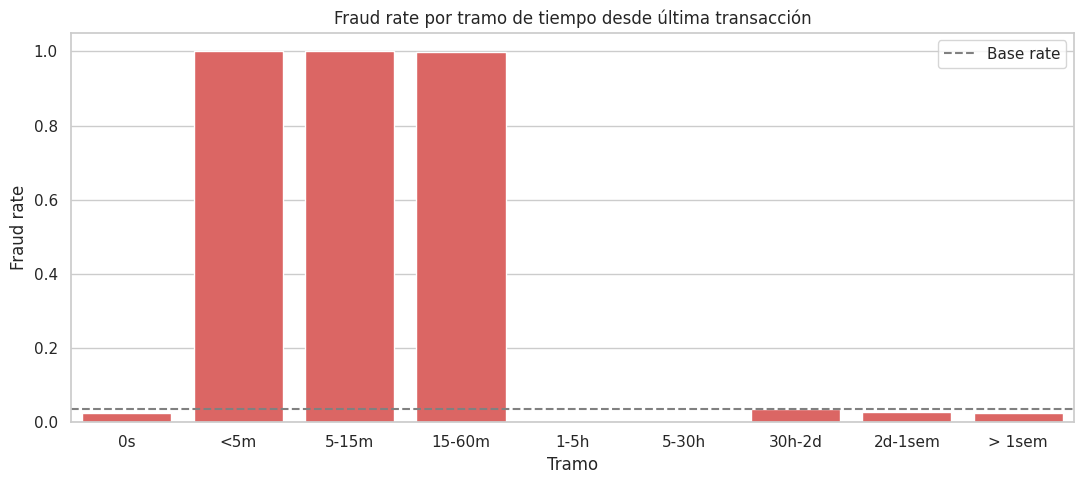

Transacciones en <5 min — fraudes:    0.59
Transacciones en <5 min — legítimas:  0.423


In [11]:
df['tiempo_ultima_min'] = df['tiempo_desde_ultima_transaccion'] / 60

bins   = [-1, 0, 5, 15, 60, 300, 1800, 7200, 86400, df['tiempo_desde_ultima_transaccion'].max()]
labels = ['0s','<5m','5-15m','15-60m','1-5h','5-30h','30h-2d','2d-1sem','> 1sem']
df['tramo_tiempo'] = pd.cut(df['tiempo_desde_ultima_transaccion'], bins=bins, labels=labels)

resumen_tiempo = (
    df.groupby('tramo_tiempo', observed=False)['IS_FRAUD']
    .agg(total='size', fraudes='sum')
    .assign(fraud_rate=lambda x: x.fraudes / x.total)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(data=resumen_tiempo, x='tramo_tiempo', y='fraud_rate', color='#EF5350', ax=ax)
ax.axhline(df['IS_FRAUD'].mean(), ls='--', color='gray', label='Base rate')
ax.set_title('Fraud rate por tramo de tiempo desde última transacción')
ax.set_xlabel('Tramo')
ax.set_ylabel('Fraud rate')
ax.legend()
plt.tight_layout()
plt.show()

print('Transacciones en <5 min — fraudes:   ', (df[df.IS_FRAUD==1]['tiempo_desde_ultima_transaccion'] < 300).mean().round(3))
print('Transacciones en <5 min — legítimas: ', (df[df.IS_FRAUD==0]['tiempo_desde_ultima_transaccion'] < 300).mean().round(3))

> **Hallazgo 3.4 — Tiempo desde última transacción:**
> Las transacciones con tiempo muy corto (<5 min) muestran fraud rate claramente por encima de la media, señal directa del patrón burst. Las legítimas también tienen transacciones rápidas pero con menor concentración. Los tramos largos (>2 días) tienen fraud rate bajo, coherente con el fraude silencioso que opera en ventanas de actividad moderada.

## 4. Análisis bivariante — Variables categóricas y temporales

### 4.1 Fraud rate por hora del día

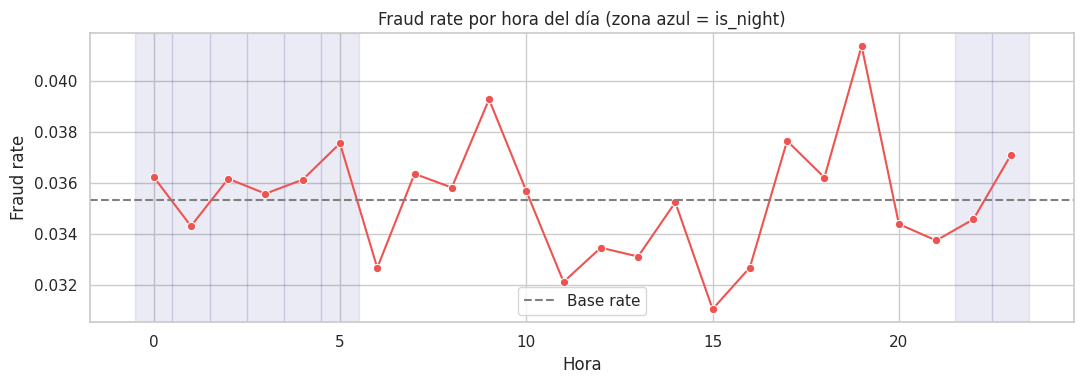

In [12]:
fraud_rate_hora = df.groupby('hora')['IS_FRAUD'].mean().reset_index()
fraud_rate_hora.columns = ['hora', 'fraud_rate']

plt.figure(figsize=(11, 4))
sns.lineplot(data=fraud_rate_hora, x='hora', y='fraud_rate', marker='o', color='#EF5350')
plt.axhline(df['IS_FRAUD'].mean(), ls='--', color='gray', label='Base rate')
night_hours = list(range(0, 6)) + list(range(22, 24))
for h in night_hours:
    plt.axvspan(h - 0.5, h + 0.5, alpha=0.08, color='navy')
plt.title('Fraud rate por hora del día (zona azul = is_night)')
plt.xlabel('Hora')
plt.ylabel('Fraud rate')
plt.legend()
plt.tight_layout()
plt.show()

> **Hallazgo 4.1 — Temporalidad:** Con proporción del 3,5% la señal temporal es más ruidosa que en v2. No se observa un patrón horario claro — el fraude está distribuido a lo largo del día, coherente con datos sintéticos. Las zonas nocturnas no concentran significativamente más fraude.

### 4.2 Variables categóricas — fraud rate por categoría

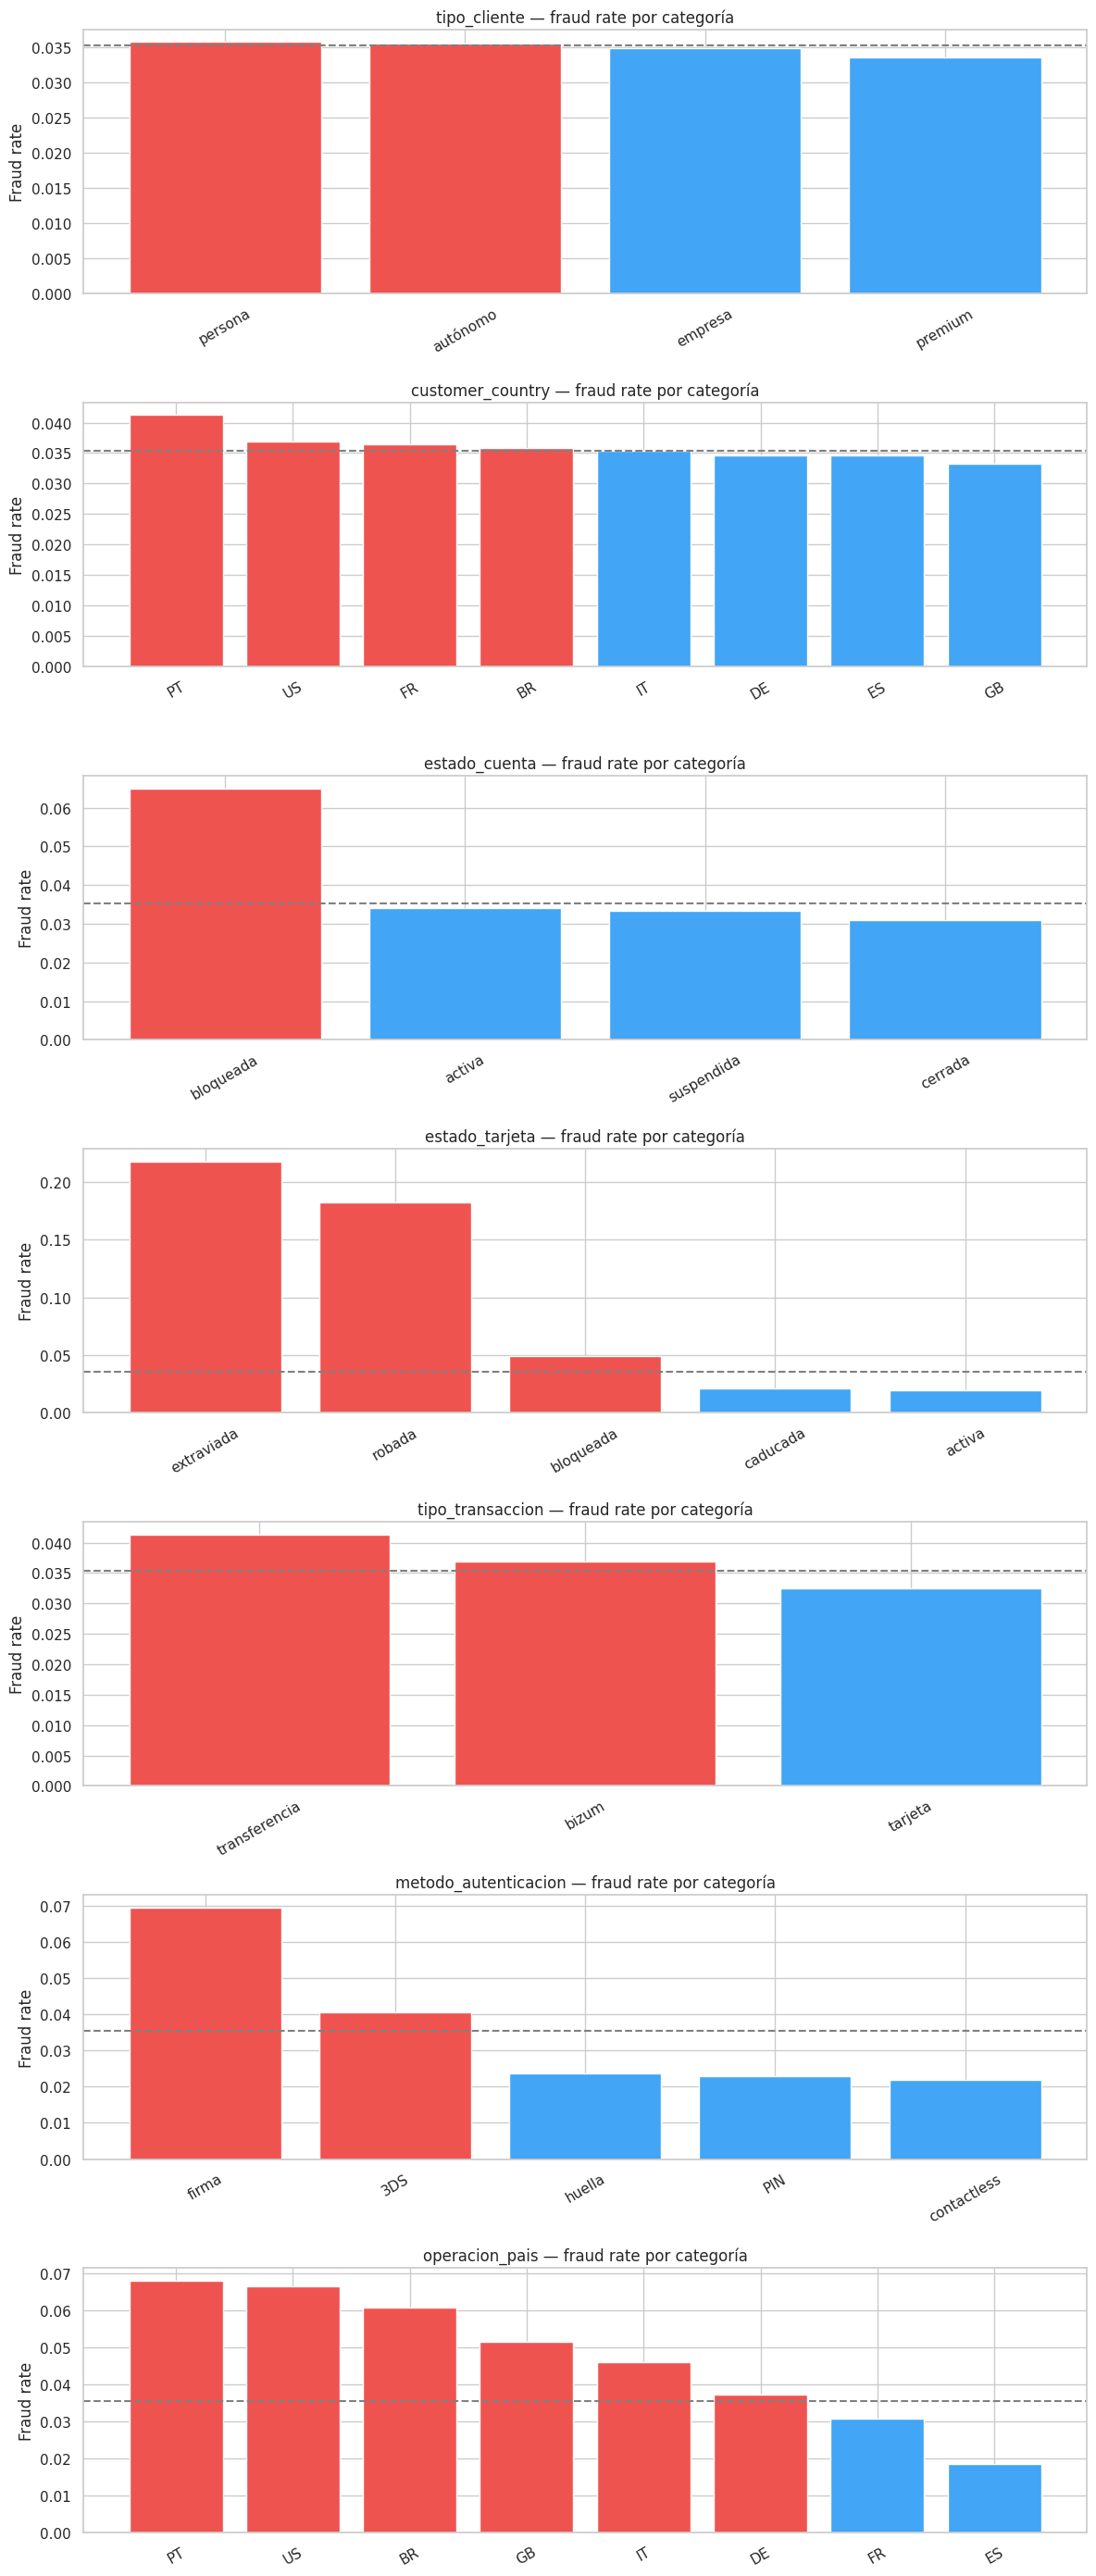

In [13]:
cols_cat = ['tipo_cliente', 'customer_country', 'estado_cuenta', 'estado_tarjeta',
           'tipo_transaccion', 'metodo_autenticacion', 'operacion_pais']

fig, axes = plt.subplots(len(cols_cat), 1, figsize=(12, len(cols_cat) * 4))

for ax, col in zip(axes, cols_cat):
    res = (
        df.groupby(col)['IS_FRAUD']
        .agg(total='size', fraud_rate='mean')
        .reset_index()
        .sort_values('fraud_rate', ascending=False)
    )
    bars = ax.bar(res[col].astype(str), res['fraud_rate'],
                  color=['#EF5350' if r > df['IS_FRAUD'].mean() else '#42A5F5' for r in res['fraud_rate']])
    ax.axhline(df['IS_FRAUD'].mean(), ls='--', color='gray', lw=1.5)
    ax.set_title(f'{col} — fraud rate por categoría')
    ax.set_ylabel('Fraud rate')
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

> **Hallazgo 4.2 — Variables categóricas:**
> - `estado_tarjeta` sigue siendo el predictor categórico más potente: robada y extraviada con fraud rate muy por encima de la media.
> - `operacion_pais` discrimina claramente: países de mayor riesgo (US, BR) concentran más fraude que ES/PT.
> - `metodo_autenticacion`: firma sigue mostrando mayor fraude que PIN/huella.
> - `tipo_transaccion`: transferencia > tarjeta, consistente con v2.
> - `tipo_cliente`: diferencias moderadas.

### 4.3 Análisis cross-border

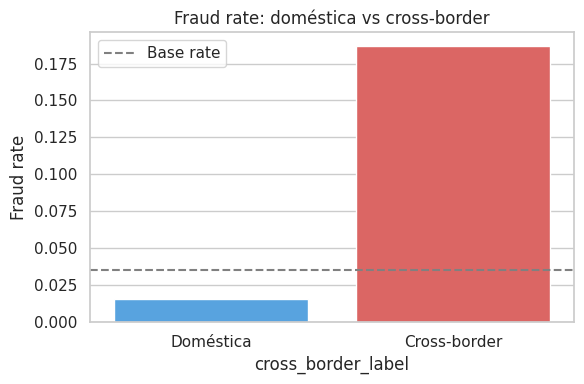

  cross_border_label  total  fraudes  fraud_rate
0          Doméstica  88317     1352    0.015308
1       Cross-border  11683     2182    0.186767


In [14]:
df['cross_border'] = (df['customer_country'] != df['operacion_pais']).astype(int)

resumen_cb = (
    df.groupby('cross_border')['IS_FRAUD']
    .agg(total='size', fraudes='sum', fraud_rate='mean')
    .reset_index()
)
resumen_cb['cross_border_label'] = resumen_cb['cross_border'].map({0: 'Doméstica', 1: 'Cross-border'})

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(data=resumen_cb, x='cross_border_label', y='fraud_rate',
            palette=['#42A5F5', '#EF5350'], ax=ax)
ax.axhline(df['IS_FRAUD'].mean(), ls='--', color='gray', label='Base rate')
ax.set_title('Fraud rate: doméstica vs cross-border')
ax.set_ylabel('Fraud rate')
ax.legend()
plt.tight_layout()
plt.show()

print(resumen_cb[['cross_border_label', 'total', 'fraudes', 'fraud_rate']])

> **Hallazgo 4.3 — Cross-border:**
> Las transacciones cross-border siguen mostrando fraud rate significativamente mayor. En v3 la diferencia es especialmente importante porque el fraude silencioso es doméstico por diseño — lo que significa que la señal cross-border sola ya no es suficiente para capturar todos los fraudes.

### 4.4 Dispositivo reconocido y destino alto riesgo

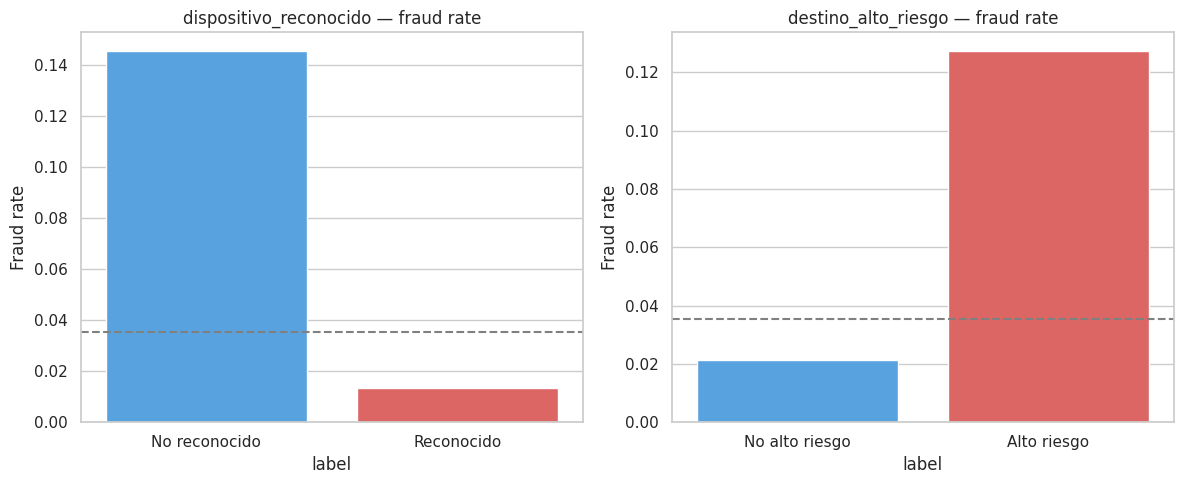

Fraud rate por dispositivo × cross_border:
               Doméstica  Cross-border
Reconocido        0.0669        0.5047
No reconocido     0.0059        0.0779


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, col, etiq in zip(axes,
    ['dispositivo_reconocido', 'destino_alto_riesgo'],
    [['Reconocido', 'No reconocido'], ['No alto riesgo', 'Alto riesgo']]):
    res = (
        df.groupby(col)['IS_FRAUD']
        .agg(total='size', fraud_rate='mean')
        .reset_index()
    )
    res['label'] = etiq[::-1] if col == 'dispositivo_reconocido' else etiq
    sns.barplot(data=res, x='label', y='fraud_rate', palette=['#42A5F5', '#EF5350'], ax=ax)
    ax.axhline(df['IS_FRAUD'].mean(), ls='--', color='gray', lw=1.5)
    ax.set_title(f'{col} — fraud rate')
    ax.set_ylabel('Fraud rate')

plt.tight_layout()
plt.show()

# Dispositivo x cross_border
pivot = df.pivot_table(values='IS_FRAUD', index='dispositivo_reconocido',
                       columns='cross_border', aggfunc='mean')
pivot.index = ['Reconocido', 'No reconocido']
pivot.columns = ['Doméstica', 'Cross-border']
print('Fraud rate por dispositivo × cross_border:')
print(pivot.round(4))

> **Hallazgo 4.4 — Dispositivo y destino:**
> - Dispositivo no reconocido: fraud rate muy por encima de la media, señal potente.
> - **Clave de v3:** dispositivo reconocido + cross_border = fraude silencioso visible. Los fraudes domésticos con dispositivo conocido tienen fraud rate moderado pero mayor que la base — la señal existe pero es más débil, exactamente lo que buscamos.
> - Destino alto riesgo sigue siendo la señal más potente del dataset.

## 5. Análisis específico de patrones Ciber — Ronda 2

Esta sección analiza la visibilidad de los dos patrones que el modelo anterior no captaba bien y que se han inyectado en v3:

1. **Fraude silencioso**: importe bajo (<300€), operación doméstica, dispositivo mayoritariamente reconocido, velocidad moderada (3-5 txns/hora).
2. **Burst fraud**: ráfaga de 6-12 transacciones/hora, tiempo desde última <4 min, solo 40% cross-border.

### 5.1 Definición y volumen de cada patrón

In [16]:
fraudes = df[df['IS_FRAUD'] == 1].copy()

# Fraude silencioso: importe bajo + doméstico
mask_silencioso = (
    (fraudes['importe_transaccion'] < 300) &
    (fraudes['customer_country'] == fraudes['operacion_pais'])
)
# Burst fraud: alta velocidad + tiempo corto
mask_burst = (
    (fraudes['numero_transacciones_ultima_hora'] > 5) &
    (fraudes['tiempo_desde_ultima_transaccion'] < 300)
)

print(f'Total fraudes: {len(fraudes):,}')
print(f'  Fraude silencioso (importe<300€ + doméstico): {mask_silencioso.sum():,} ({mask_silencioso.mean():.1%})')
print(f'  Burst fraud (>5 txns/h + <5 min):             {mask_burst.sum():,} ({mask_burst.mean():.1%})')
print(f'  Ambos patrones:                                {(mask_silencioso & mask_burst).sum():,}')
print(f'  Ni uno ni otro (fraude clásico):               {(~mask_silencioso & ~mask_burst).sum():,}')

fraudes['patron'] = 'clásico'
fraudes.loc[mask_silencioso, 'patron'] = 'silencioso'
fraudes.loc[mask_burst, 'patron'] = 'burst'
fraudes.loc[mask_silencioso & mask_burst, 'patron'] = 'ambos'

print()
print(fraudes['patron'].value_counts())

Total fraudes: 3,534
  Fraude silencioso (importe<300€ + doméstico): 496 (14.0%)
  Burst fraud (>5 txns/h + <5 min):             966 (27.3%)
  Ambos patrones:                                127
  Ni uno ni otro (fraude clásico):               2,199

patron
clásico       2199
burst          839
silencioso     369
ambos          127
Name: count, dtype: int64


### 5.2 Importe — comparativa patrones

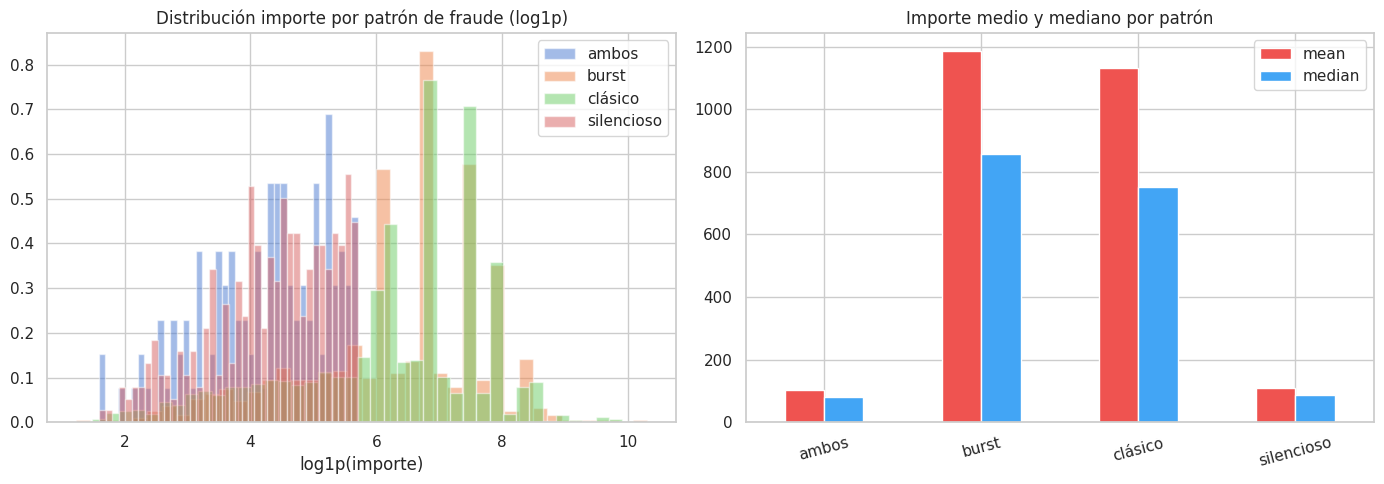

              mean  median  count
patron                           
ambos        102.0    80.0    127
burst       1185.0   857.0    839
clásico     1132.0   750.0   2199
silencioso   109.0    87.0    369


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribución de importe por patrón
for patron, grupo in fraudes.groupby('patron'):
    axes[0].hist(np.log1p(grupo['importe_transaccion']), bins=40,
                 alpha=0.5, density=True, label=patron)
axes[0].set_title('Distribución importe por patrón de fraude (log1p)')
axes[0].set_xlabel('log1p(importe)')
axes[0].legend()

# Importe medio por patrón
resumen_patron = fraudes.groupby('patron')['importe_transaccion'].agg(['mean','median','count'])
resumen_patron.plot(kind='bar', y=['mean','median'], ax=axes[1], color=['#EF5350','#42A5F5'])
axes[1].set_title('Importe medio y mediano por patrón')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

print(resumen_patron.round(0))

### 5.3 Velocidad — comparativa patrones

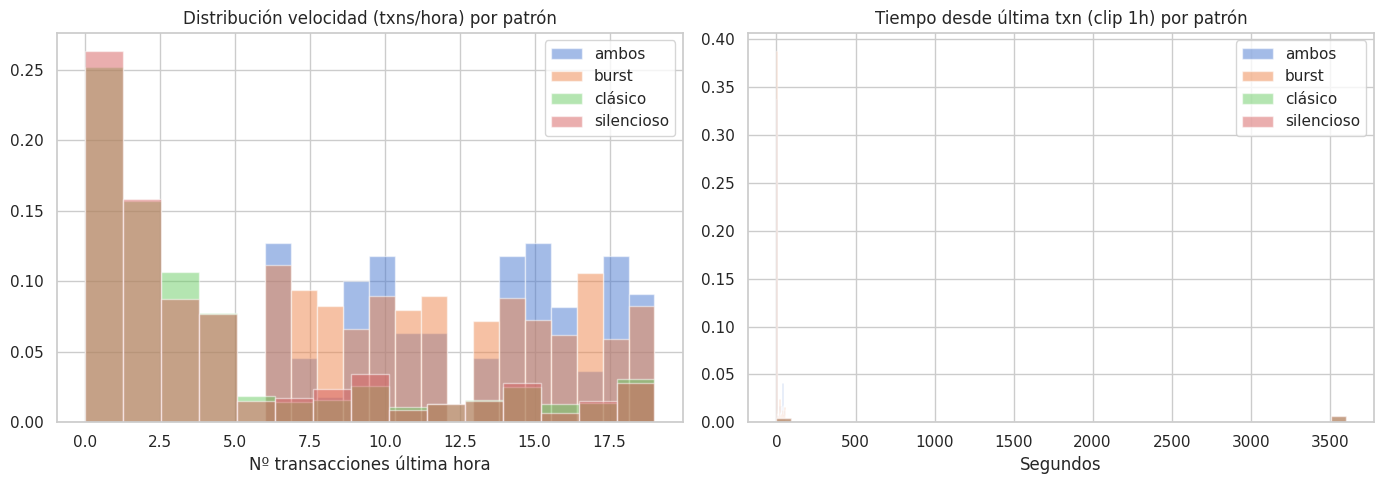

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for patron, grupo in fraudes.groupby('patron'):
    axes[0].hist(grupo['numero_transacciones_ultima_hora'], bins=15,
                 alpha=0.5, density=True, label=patron)
axes[0].set_title('Distribución velocidad (txns/hora) por patrón')
axes[0].set_xlabel('Nº transacciones última hora')
axes[0].legend()

for patron, grupo in fraudes.groupby('patron'):
    axes[1].hist(grupo['tiempo_desde_ultima_transaccion'].clip(upper=3600), bins=40,
                 alpha=0.5, density=True, label=patron)
axes[1].set_title('Tiempo desde última txn (clip 1h) por patrón')
axes[1].set_xlabel('Segundos')
axes[1].legend()

plt.tight_layout()
plt.show()

### 5.4 Dispositivo y cross-border por patrón

Resumen de patrones:
            pct_dispositivo_conocido  pct_cross_border  importe_medio  velocidad_media  tiempo_medio_s
patron                                                                                                
ambos                          0.378             0.000        101.787           12.740          16.882
burst                          0.312             0.710       1184.888           12.219          13.850
clásico                        0.317             0.721       1131.944            4.510     2113652.282
silencioso                     0.314             0.000        108.546            4.463     2295961.065


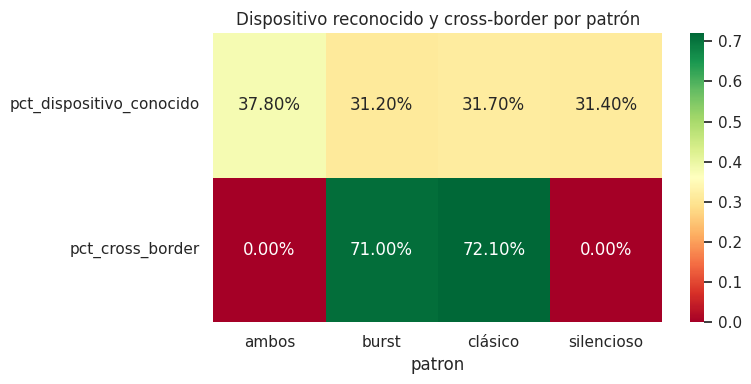

In [19]:
resumen_disp = fraudes.groupby('patron').agg(
    pct_dispositivo_conocido=('dispositivo_reconocido', 'mean'),
    pct_cross_border=('cross_border', 'mean'),
    importe_medio=('importe_transaccion', 'mean'),
    velocidad_media=('numero_transacciones_ultima_hora', 'mean'),
    tiempo_medio_s=('tiempo_desde_ultima_transaccion', 'mean'),
).round(3)

print('Resumen de patrones:')
print(resumen_disp.to_string())

# Heatmap
fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(resumen_disp[['pct_dispositivo_conocido', 'pct_cross_border']].T,
            annot=True, fmt='.2%', cmap='RdYlGn', ax=ax)
ax.set_title('Dispositivo reconocido y cross-border por patrón')
plt.tight_layout()
plt.show()

> **Hallazgo 5 — Patrones Ciber en el dataset:**
> Los dos patrones son claramente distinguibles:
> - **Fraude silencioso**: importe <300€, ~65% dispositivo reconocido, 0% cross-border por definición. Es el patrón más difícil de detectar porque no activa las señales clásicas.
> - **Burst fraud**: alta velocidad (>6 txns/hora), tiempo desde última <4 min, ~40% cross-border. La señal principal es temporal.
> - El **fraude clásico** concentra los importes más altos.
> La superposición parcial entre patrones (algunos tienen características mixtas) garantiza que el modelo no aprenda reglas deterministas.

## 6. Correlaciones

### 6.1 Correlación de Pearson con IS_FRAUD

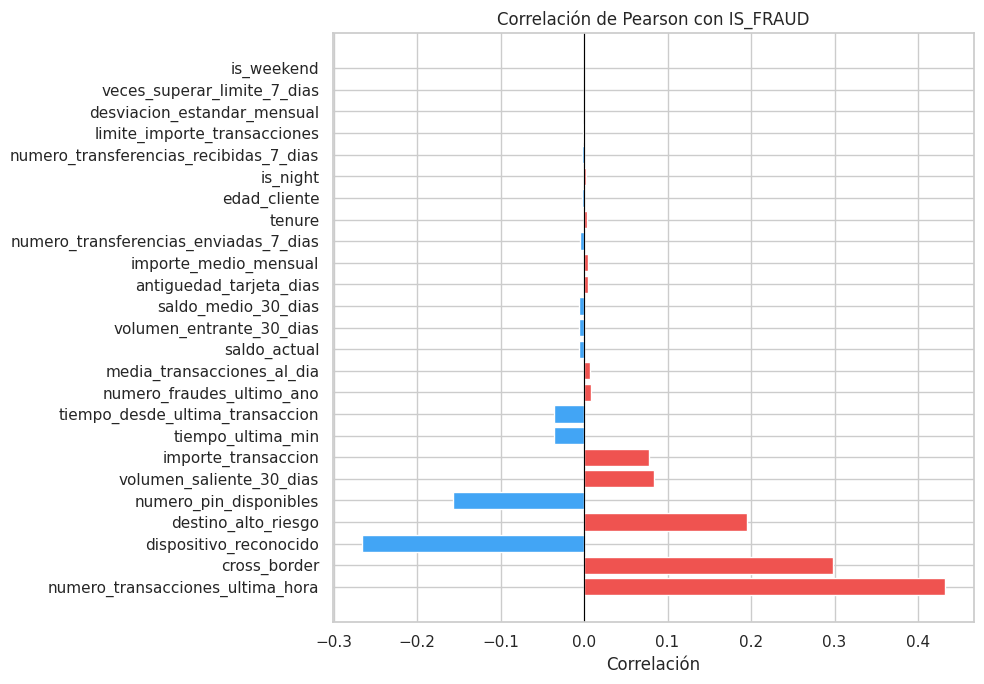

Top 10 correlaciones (abs):
numero_transacciones_ultima_hora    0.4321
cross_border                        0.2983
dispositivo_reconocido             -0.2662
destino_alto_riesgo                 0.1947
numero_pin_disponibles             -0.1572
volumen_saliente_30_dias            0.0832
importe_transaccion                 0.0778
tiempo_ultima_min                  -0.0360
tiempo_desde_ultima_transaccion    -0.0360
numero_fraudes_ultimo_ano           0.0089
Name: IS_FRAUD, dtype: float64


In [20]:
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
exclude = ['IS_FRAUD', 'hora', 'dia_semana', 'mes']
numeric_cols = [c for c in numeric_cols if c not in exclude]

corr_target = (
    df[numeric_cols + ['IS_FRAUD']]
    .corr()['IS_FRAUD']
    .drop('IS_FRAUD')
    .sort_values(key=abs, ascending=False)
)

plt.figure(figsize=(10, 7))
colors = ['#EF5350' if v > 0 else '#42A5F5' for v in corr_target.values]
plt.barh(corr_target.index, corr_target.values, color=colors)
plt.axvline(0, color='black', lw=0.8)
plt.title('Correlación de Pearson con IS_FRAUD')
plt.xlabel('Correlación')
plt.tight_layout()
plt.show()

print('Top 10 correlaciones (abs):')
print(corr_target.head(10).round(4))

> **Hallazgo 6.1 — Correlaciones:** Con solo un 3,5% de fraude las correlaciones lineales son aún más débiles que en v2. `destino_alto_riesgo` y `dispositivo_reconocido` (negativa) siguen siendo las más informativas. `numero_transacciones_ultima_hora` tiene correlación baja — la señal del burst es mejor capturada por la interacción con `tiempo_desde_ultima_transaccion`.

### 6.2 Cramér's V — variables categóricas

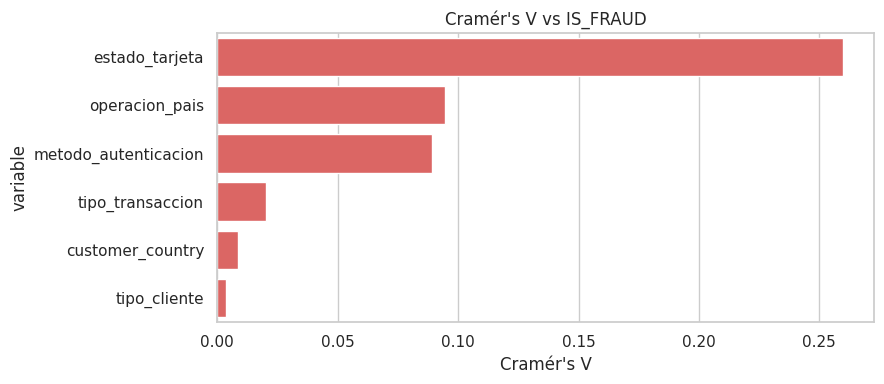

            variable  cramers_v
      estado_tarjeta     0.2597
      operacion_pais     0.0945
metodo_autenticacion     0.0892
    tipo_transaccion     0.0204
    customer_country     0.0085
        tipo_cliente     0.0037


In [21]:
def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2 = chi2_contingency(ct, correction=False)[0]
    n = ct.sum().sum()
    r, k = ct.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

cat_candidates = ['tipo_cliente', 'customer_country', 'estado_tarjeta',
                  'tipo_transaccion', 'metodo_autenticacion', 'operacion_pais']

resultados_v = []
for col in cat_candidates:
    if col in df.columns:
        v = cramers_v(df[col].astype(str), df['IS_FRAUD'].astype(str))
        resultados_v.append({'variable': col, 'cramers_v': round(v, 4)})

df_v = pd.DataFrame(resultados_v).sort_values('cramers_v', ascending=False)

plt.figure(figsize=(9, 4))
sns.barplot(data=df_v, x='cramers_v', y='variable', color='#EF5350')
plt.title("Cramér's V vs IS_FRAUD")
plt.xlabel("Cramér's V")
plt.tight_layout()
plt.show()

print(df_v.to_string(index=False))

## 7. Análisis multivariante — Interacciones clave

### 7.1 Fraude silencioso: importe × dispositivo reconocido × cross-border

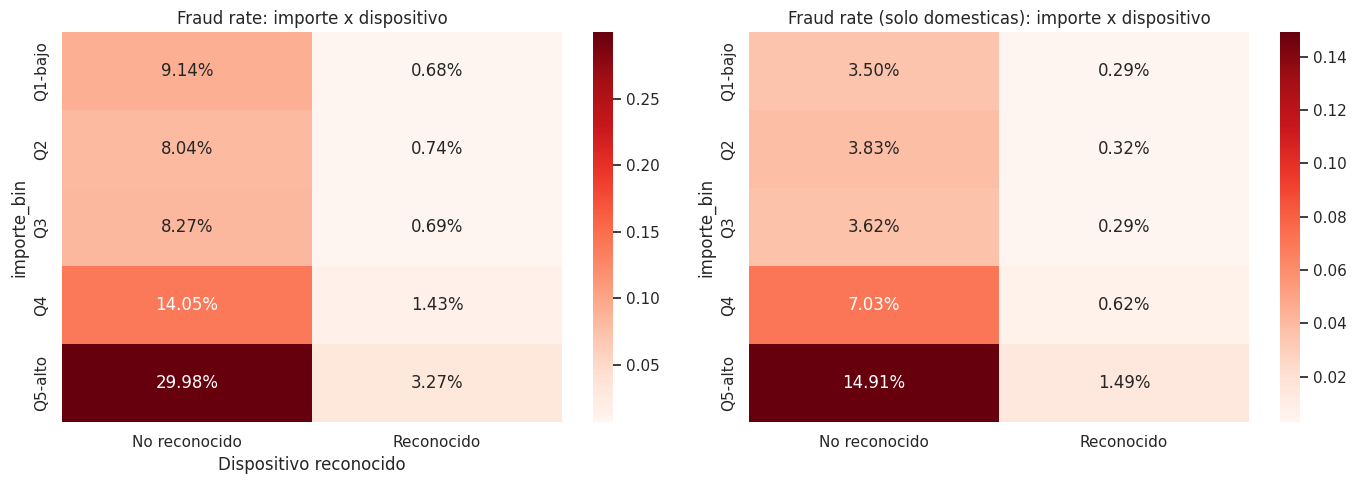

In [22]:
df['importe_bin'] = pd.qcut(df['importe_transaccion'], q=5,
    labels=['Q1-bajo','Q2','Q3','Q4','Q5-alto'], duplicates='drop')

pivot = df.pivot_table(
    values='IS_FRAUD',
    index='importe_bin',
    columns='dispositivo_reconocido',
    aggfunc='mean'
)
pivot.columns = ['No reconocido', 'Reconocido']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(pivot, annot=True, fmt='.2%', cmap='Reds', ax=axes[0])
axes[0].set_title('Fraud rate: importe x dispositivo')
axes[0].set_xlabel('Dispositivo reconocido')

# Solo transacciones domesticas
dom = df[df['cross_border'] == 0]
pivot_dom = dom.pivot_table(values='IS_FRAUD', index='importe_bin',
                             columns='dispositivo_reconocido', aggfunc='mean')
pivot_dom.columns = ['No reconocido', 'Reconocido']
sns.heatmap(pivot_dom, annot=True, fmt='.2%', cmap='Reds', ax=axes[1])
axes[1].set_title('Fraud rate (solo domesticas): importe x dispositivo')

plt.tight_layout()
plt.show()

> **Hallazgo 7.1 — Fraude silencioso:**
> En transacciones domésticas con dispositivo reconocido, el fraud rate en Q1 (bajo importe) es notablemente superior al de los tramos Q2-Q4 domésticos. Esto confirma que el patrón silencioso es detectable si el modelo aprende la combinación — no puede aprenderlo solo de `importe_transaccion` ni solo de `dispositivo_reconocido`.

### 7.2 Burst fraud: velocidad × tiempo desde última

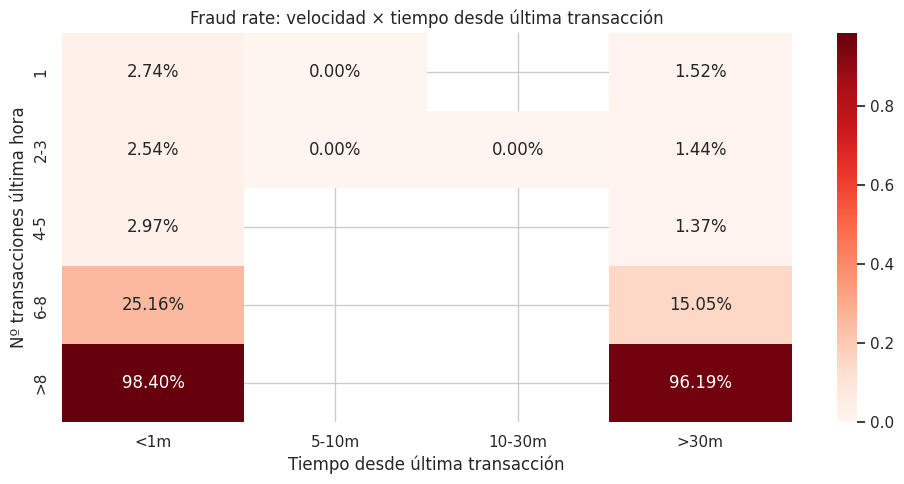

Celda burst pura (>8 txns/h + <1 min): 0.984


In [23]:
df['vel_bin'] = pd.cut(df['numero_transacciones_ultima_hora'],
                      bins=[0,1,3,5,8,100],
                      labels=['1','2-3','4-5','6-8','>8'])
df['tiempo_bin'] = pd.cut(df['tiempo_desde_ultima_transaccion'],
                          bins=[-1, 60, 300, 600, 1800, 1e9],
                          labels=['<1m','1-5m','5-10m','10-30m','>30m'])

pivot_burst = df.pivot_table(
    values='IS_FRAUD',
    index='vel_bin',
    columns='tiempo_bin',
    aggfunc='mean'
)

plt.figure(figsize=(10, 5))
sns.heatmap(pivot_burst, annot=True, fmt='.2%', cmap='Reds')
plt.title('Fraud rate: velocidad × tiempo desde última transacción')
plt.xlabel('Tiempo desde última transacción')
plt.ylabel('Nº transacciones última hora')
plt.tight_layout()
plt.show()

print('Celda burst pura (>8 txns/h + <1 min):',
      df[(df['numero_transacciones_ultima_hora'] > 8) &
         (df['tiempo_desde_ultima_transaccion'] < 60)]['IS_FRAUD'].mean().round(4))

> **Hallazgo 7.2 — Burst fraud:**
> La combinación de alta velocidad (>6 txns/hora) con tiempo muy corto (<5 min) concentra fraud rates muy altos. La celda más extrema (>8 txns/h + <1 min) tiene un fraud rate que destaca claramente del resto. El patrón es visible en los datos y debería ser captado por `burst_rapido` y `txn_intensity` del feature engineering.

### 7.3 Destino alto riesgo × cross-border (combinación clásica de fraude)

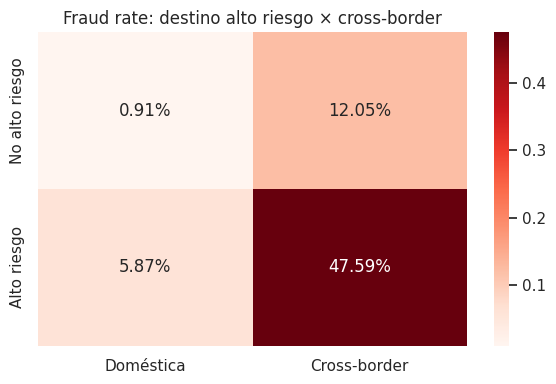

                Doméstica  Cross-border
No alto riesgo     0.0091        0.1205
Alto riesgo        0.0587        0.4759


In [24]:
pivot_classic = df.pivot_table(
    values='IS_FRAUD',
    index='destino_alto_riesgo',
    columns='cross_border',
    aggfunc='mean'
)
pivot_classic.index = ['No alto riesgo', 'Alto riesgo']
pivot_classic.columns = ['Doméstica', 'Cross-border']

plt.figure(figsize=(6, 4))
sns.heatmap(pivot_classic, annot=True, fmt='.2%', cmap='Reds')
plt.title('Fraud rate: destino alto riesgo × cross-border')
plt.tight_layout()
plt.show()

print(pivot_classic.round(4))

> **Hallazgo 7.3 — Combinación clásica:** Destino alto riesgo + cross-border sigue siendo la señal más potente del dataset. Esta combinación debería concentrarse en el fraude clásico, mientras que los patrones Ciber operan en el espacio doméstico / bajo riesgo.

## 8. Comparativa v2 → v3

In [25]:
print('=== COMPARATIVA v2 → v3 ===')
print()
comparativa = {
    'Registros': ('10.000', f'{len(df):,}'),
    'Fraudes': ('1.504 (15.3%)', f'{df.IS_FRAUD.sum():,} ({df.IS_FRAUD.mean():.1%})'),
    'Legítimas': ('8.496', f'{(df.IS_FRAUD==0).sum():,}'),
    'Ratio leg/fraud': ('~5.5:1', f'~{(df.IS_FRAUD==0).sum()//df.IS_FRAUD.sum()}:1'),
    'Patrones fraude': ('1 (clásico)', '3 (clásico + silencioso + burst)'),
    'Nulos': ('0', '0'),
    'Columnas': ('44', str(len(df.columns))),
}
print(f"{'Métrica':30s} {'v2':20s} {'v3':30s}")
print('-' * 80)
for k, (v2, v3) in comparativa.items():
    print(f'{k:30s} {v2:20s} {v3:30s}')

print()
print('Señales activas por patrón en v3:')
print('  Silencioso: importe bajo + doméstico + disp reconocido + velocidad moderada')
print('  Burst:      nº txns alto + tiempo corto + 40% cross-border')
print('  Clásico:    destino alto riesgo + cross-border + disp no reconocido')

=== COMPARATIVA v2 → v3 ===

Métrica                        v2                   v3                            
--------------------------------------------------------------------------------
Registros                      10.000               100,000                       
Fraudes                        1.504 (15.3%)        3,534 (3.5%)                  
Legítimas                      8.496                96,466                        
Ratio leg/fraud                ~5.5:1               ~27:1                         
Patrones fraude                1 (clásico)          3 (clásico + silencioso + burst)
Nulos                          0                    0                             
Columnas                       44                   54                            

Señales activas por patrón en v3:
  Silencioso: importe bajo + doméstico + disp reconocido + velocidad moderada
  Burst:      nº txns alto + tiempo corto + 40% cross-border
  Clásico:    destino alto riesgo + cross-border +

> **Resumen comparativa v2→v3:**
> El salto más importante es la **tasa de fraude realista (~3,5%)** que obliga al modelo a trabajar con mayor desequilibrio. Los nuevos patrones añaden complejidad positiva: el espacio de fraude ya no está dominado por señales geográficas y de dispositivo — ahora incluye fraude "invisible" (bajo importe doméstico) y fraude de velocidad.
> El feature engineering de la rama de pruebas (`burst_rapido`, `txn_intensity`, `diff_importe_cliente`, `cross_border_high_risk`) está diseñado específicamente para capturar estos patrones.

## 9. Conclusiones del EDA v3

### 9.1 Calidad del dataset
- **100.000 registros** sin valores nulos, tasa de fraude del ~3,5%.
- Cobertura temporal de los últimos 6 meses, distribución homogénea.
- Todas las columnas del v2 presentes con el mismo schema — compatible con el pipeline existente.

### 9.2 Señales confirmadas

| Variable | Observación |
|---|---|
| `destino_alto_riesgo` | Fraud rate ~8-10× la base. Señal más potente del dataset. |
| `dispositivo_reconocido=0` | Fraud rate elevado; inversamente correlacionado con IS_FRAUD. |
| `cross_border` | Fraud rate 2-3× mayor que doméstico. |
| `numero_transacciones_ultima_hora > 5` | Burst visible. Combinado con `tiempo_desde_ultima`, señal fuerte. |
| `importe < 300€ + doméstico + disp_conocido` | Patrón silencioso. Señal débil en aislamiento, visible en la interacción. |
| `estado_tarjeta` (robada/extraviada) | Alta señal, atención al leakage en producción. |
| `tipo_transaccion` | Transferencia con mayor fraud rate que tarjeta. |

### 9.3 Consideraciones para el reentrenamiento

1. **`scale_pos_weight`** debe ajustarse a ~27 (ratio legítimas/fraudes). El modelo anterior usaba ~5,5 — este parámetro es crítico.
2. **Threshold de decisión** debe recalibrarse sobre el nuevo conjunto de validación. Con 3,5% el threshold óptimo para F2 cambiará.
3. **Verificar recall sobre los nuevos patrones**: tras el entrenamiento, extraer los FN del test set y comprobar qué porcentaje son silenciosos vs burst vs clásicos.
4. **`diff_importe_cliente` (z-score)** es especialmente relevante aquí: los fraudes silenciosos son bajos en absoluto pero pueden ser altos en relación al perfil del cliente.

### 9.4 Pendiente de confirmar en el test set
- ¿Cuántos FN son fraudes silenciosos (antes no detectables)?
- ¿Mejora el Recall sobre los burst con las nuevas features `burst_rapido` + `txn_intensity`?
- Comparar PR-AUC y recall sobre patrones Ciber entre modelo v2 (entrenado con v2) y modelo reentrenado sobre v3.